In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind))

def decodifica(genotipo, rango):
    Nvar = rango.shape[0]
    Nind, Lind = genotipo.shape
    Lvar = Lind // Nvar
    potencias = 2 ** np.arange(Lvar)[::-1]
    fenotipo = np.zeros((Nind, Nvar))
    
    for i in range(Nind):
        for j in range(Nvar):
            bits = genotipo[i, (j * Lvar):(j * Lvar + Lvar)]
            fenotipo[i, j] = np.sum(potencias * bits)
            
    for i in range(Nvar):
        fenotipo[:, i] = rango[i, 0] + ((rango[i, 1] - rango[i, 0]) / ((2 ** Lvar) - 1)) * fenotipo[:, i]
        
    return fenotipo

def objfun(fenotipo):
    Nind = fenotipo.shape[0]
    objv = np.zeros((Nind, 1))
    for i in range(Nind):
        x = fenotipo[i, 0]
        # Función: f(x) = [1 - (11/2 x - 7/2)^2][cos(11/2 x - 7/2) + 1] + 2
        term1 = 1 - ((11.0 / 2.0) * x - (7.0 / 2.0))**2
        term2 = np.cos((11.0 / 2.0) * x - (7.0 / 2.0)) + 1
        objv[i, 0] = term1 * term2 + 2
    return objv

def ruleta(genotipo, aptitud):
    # Selección proporcional por ruleta basada en F(x) directamente (según PDF)
    Nind = aptitud.shape[0]
    total = np.sum(aptitud)
    probabilidad = aptitud / total
    acumulada = np.cumsum(probabilidad)
    idx = np.zeros((Nind, 1), dtype=int)
    
    for i in range(Nind):
        selecciona = np.random.rand()
        aux_idx = np.where(acumulada >= selecciona)[0]
        if len(aux_idx) > 0:
            idx[i, 0] = aux_idx[0]
        else:
            idx[i, 0] = Nind - 1
            
    nuevo_gen = genotipo[idx.flatten(), :]
    return nuevo_gen

def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = np.zeros((Nind, Lind), dtype=int)
    par = Nind % 2
    
    for i in range(0, Nind - par, 2):
        cruza = np.random.rand()
        if cruza <= Pc:
            corte = np.random.randint(1, Lind - 1) if Lind > 2 else 1
            aux_gen[i] = np.concatenate((nuevo_gen[i, :corte], nuevo_gen[i + 1, corte:]))
            aux_gen[i + 1] = np.concatenate((nuevo_gen[i + 1, :corte], nuevo_gen[i, corte:]))
        else:
            aux_gen[i, :] = nuevo_gen[i, :]
            aux_gen[i + 1, :] = nuevo_gen[i + 1, :]
            
    if par == 1:
        aux_gen[Nind - 1, :] = nuevo_gen[Nind - 1, :]
        
    return aux_gen

def muta(nuevo_gen, Pm):
    Nind, Lind = nuevo_gen.shape
    valores = np.random.rand(Nind, Lind)
    muta_matrix = valores <= Pm
    nuevo_gen = np.logical_xor(nuevo_gen, muta_matrix).astype(int)
    return nuevo_gen

In [4]:
# Parámetros basados en las características del PDF
Nind = 5               # Tamaño de la población
Lind = 20              # Longitud de la cadena (Precisión)
Pc = 0.70              # Probabilidad de cruza
Pm = 1 / 15            # Probabilidad de mutación
Maxgen = 100           # Número de generaciones
Nvar = 1               # Número de variables (solo x)
rango = np.array([[0.0, 0.875]]) # Intervalo

# Inicialización
genotipo = creapob(Nind, Lind)
Mejor = np.full((Maxgen, 1), np.nan)
Mejor_cromosoma = np.zeros((Maxgen, Lind))

generaciones = 0

# Ciclo evolutivo
while generaciones < Maxgen:
    fenotipo = decodifica(genotipo, rango)
    objv = objfun(fenotipo)
    
    # Guardar la mejor solución de la generación
    idx = np.argmax(objv)
    Mejor[generaciones] = objv[idx]
    Mejor_cromosoma[generaciones, :] = genotipo[idx, :]
    
    # Como la tabla del PDF usa directamente f(x) para la probabilidad
    aptitud = np.maximum(objv, 0) # Asegurar que no haya fitness negativo en otros contextos
    
    # Operadores genéticos
    nuevo_gen = ruleta(genotipo, aptitud)
    nuevo_gen = xunpunto(nuevo_gen, Pc)
    nuevo_gen = muta(nuevo_gen, Pm)
    
    genotipo = nuevo_gen
    generaciones += 1

idx_global = np.nanargmax(Mejor)
mejor_x_feno = decodifica(np.array([Mejor_cromosoma[idx_global]]), rango)[0, 0]
mejor_y = Mejor[idx_global, 0]

print(f"Mejor valor de f(x) encontrado: {mejor_y:.4f}")
print(f"Valor de x que maximiza la función: {mejor_x_feno:.4f}")

Mejor valor de f(x) encontrado: 4.0000
Valor de x que maximiza la función: 0.6364


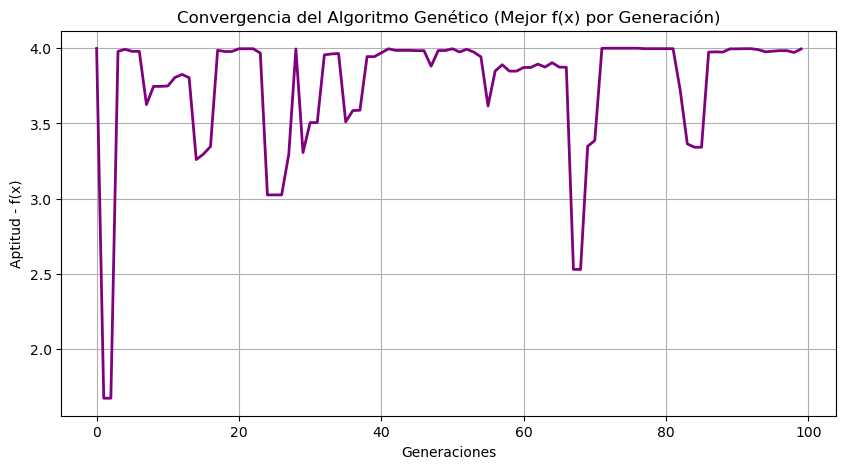

In [5]:
# Gráfica del progreso del Algoritmo Genético
plt.figure(figsize=(10, 5))
plt.plot(Mejor, color='purple', linewidth=2)
plt.title('Convergencia del Algoritmo Genético (Mejor f(x) por Generación)')
plt.xlabel('Generaciones')
plt.ylabel('Aptitud - f(x)')
plt.grid(True)
plt.show()

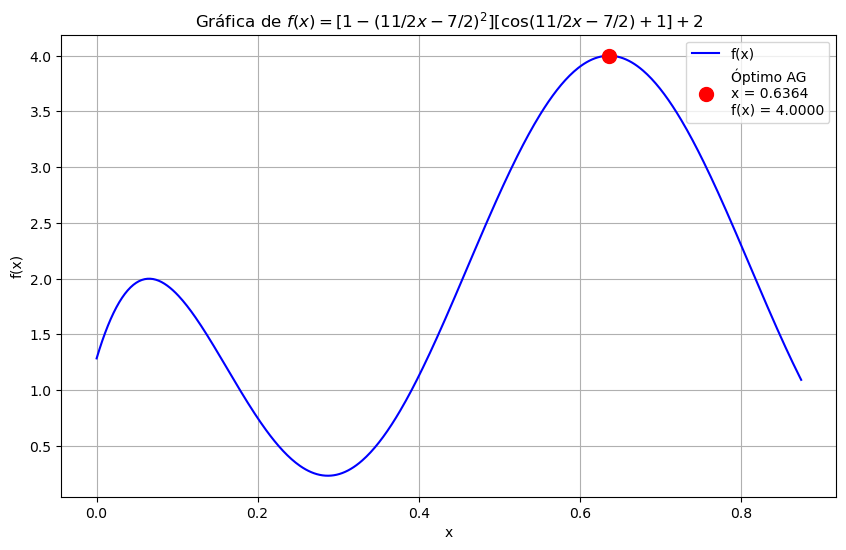

In [6]:
# Generar datos para la función original en 2D
x_vals = np.linspace(0, 0.875, 500)
term1 = 1 - ((11.0 / 2.0) * x_vals - (7.0 / 2.0))**2
term2 = np.cos((11.0 / 2.0) * x_vals - (7.0 / 2.0)) + 1
y_vals = term1 * term2 + 2

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='f(x)', color='blue')

# Graficar el punto óptimo encontrado por el AG
plt.scatter(mejor_x_feno, mejor_y, color='red', s=100, zorder=5, 
            label=f'Óptimo AG\nx = {mejor_x_feno:.4f}\nf(x) = {mejor_y:.4f}')

# Etiquetas y título
plt.title(r'Gráfica de $f(x) = [1 - (11/2x - 7/2)^2][\cos(11/2x - 7/2) + 1] + 2$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()